# Week 7 Development Notebook

## 1. Environment and shared infrastructure

### Design decisions

**State representation.** Integer states (0..499) end-to-end. Q-table is a `numpy.ndarray` of shape (500, 6); model entries are keyed by `(int_state, int_action)`. A `decode_state()` helper returns the (taxi_row, taxi_col, passenger_loc, destination) tuple and is reserved for diagnostics, logging, and post-hoc analysis only, never agent hot paths.

**Environment.** Gymnasium `Taxi-v4` in deterministic mode (default). The project-level environment class wraps `gym.make("Taxi-v4")`, exposes `reset(seed=None)` and `step(action)` returning integer states alongside `terminated` and `truncated` flags, and is agnostic to any Gymnasium wrappers stacked beneath it (e.g., the Epic 5 mutation wrapper).

**Seeding.** All determinism flows through `reset(seed=...)`. There is no construction-time seed; the env is constructed seedless and the caller (typically the training loop driver) seeds the env at the first `reset()` of each run. This yields one authoritative source of determinism per run, supports the multi-seed experiment loop pattern, and avoids the footgun where a construction-time seed could be silently overridden by a later `reset(seed=...)` call.

**Episode truncation.** Unsolved episodes truncate at step 200 via Gymnasium's `TimeLimit` wrapper, signaled by `truncated=True` (distinct from `terminated=True` for goal completion). Agents must distinguish the two when computing Q-update targets.

**Agent interface.** Agents subclass an abstract `Agent` base class and implement `act(state)` and `learn(state, action, reward, next_state, terminated, truncated)`. `learn()` returns a flexible dict; the training loop merges keys it recognizes (`wall_time_planning`, `n_planning_updates`) into per-episode aggregates and fills defaults for missing keys. Trivial agents may return an empty dict.

**Trace schema (per-episode rows; refactored 2026-04-28).** Columns: `agent_id`, `seed`, `episode`, `total_reward`, `num_steps`, `cumulative_steps`, `terminated`, `truncated`, `wall_time_episode`, `wall_time_planning_episode`, `n_planning_updates_episode`, `cumulative_planning_updates`. One row per episode rather than per real step. Per-step transition data (`state`, `action`, `next_state`) is discarded; per-step timing is summed into `wall_time_episode` (per-step time = `wall_time_episode / num_steps` when needed). The `cumulative_steps` and `cumulative_planning_updates` columns make both axes available for plotting model-based RL agents (real-step axis for sample efficiency; planning-update axis for compute cost). This schema reduced trace files by roughly two orders of magnitude (Q-learning went from ~12 MB per run to ~50 KB) without losing the data needed for the planned visualizations or the computational-trade-off analysis. The original per-step schema is reachable via the `record_per_step=True` flag on `TrainingLoop`, which currently raises `NotImplementedError` until forensic per-step recording is needed.

**Persistence.** One trace CSV per `(agent_id, seed)` run, written under `data/{agent_id}/trace_seed_{seed}.csv`, with a matching `config_seed_{seed}.json` sidecar containing `agent_id`, `seed`, `num_episodes`, `hyperparams`, and a UTC timestamp. The driver owns I/O; agents never write files. Re-running the same `(agent_id, seed)` overwrites the existing files. Reserved keys (`agent_id`, `seed`, `num_episodes`) cannot appear in user-supplied `hyperparams`; the driver records these from `run()` args directly to keep the sidecar authoritative.

**Storage format.** pandas DataFrame in memory; CSV on disk. In-memory is sufficient for Taxi-scale runs at per-episode granularity.

**Timing.** The driver wraps each real step with `time.perf_counter()` to measure step time, then sums into `wall_time_episode` per row. The agent reports `wall_time_planning` and `n_planning_updates` back to the driver as part of `learn()`'s return dict; both are summed across the episode into `wall_time_planning_episode` and `n_planning_updates_episode`.

In [1]:
# DONE: Build an environment class that wraps Gymnasium Taxi-v4 and presents
# a clean interface to agents.
# Outcome: a class exposing reset(seed=None) and step(action) returning integer
# states, rewards, terminated, and truncated; isolates agents from Gymnasium
# API details; ready to accept Gymnasium wrappers (e.g., the Epic 5 mutation
# wrapper) without changes to the class itself. Also exposes num_actions and
# num_states so callers can construct agents sized to the env without holding
# a reference to the env itself. All seeding flows through reset(seed=...) so
# that there is one authoritative source of determinism per run.

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from taxi_env import TaxiEnv

env = TaxiEnv()
print(f"num_actions: {env.num_actions}")
print(f"num_states:  {env.num_states}")

state = env.reset(seed=42)
print(f"Initial state (int): {state}")
print(f"Decoded (taxi_row, taxi_col, passenger_loc, destination): {env.decode_state(state)}")

for step_i in range(5):
    next_state, reward, terminated, truncated = env.step(action=0)
    print(
        f"step={step_i} action=0 -> next_state={next_state} "
        f"reward={reward} terminated={terminated} truncated={truncated} "
        f"decoded={env.decode_state(next_state)}"
    )
    if terminated or truncated:
        break

num_actions: 6
num_states:  500
Initial state (int): 386
Decoded (taxi_row, taxi_col, passenger_loc, destination): (3, 4, 1, 2)
step=0 action=0 -> next_state=486 reward=-1.0 terminated=False truncated=False decoded=(4, 4, 1, 2)
step=1 action=0 -> next_state=486 reward=-1.0 terminated=False truncated=False decoded=(4, 4, 1, 2)
step=2 action=0 -> next_state=486 reward=-1.0 terminated=False truncated=False decoded=(4, 4, 1, 2)
step=3 action=0 -> next_state=486 reward=-1.0 terminated=False truncated=False decoded=(4, 4, 1, 2)
step=4 action=0 -> next_state=486 reward=-1.0 terminated=False truncated=False decoded=(4, 4, 1, 2)


In [2]:
# DONE: Build a training-loop driver that runs any agent satisfying a known
# interface against the environment class.
# Outcome: a TrainingLoop class that takes an Agent (subclass of the abstract
# base) plus an env, agent_id, output_dir, and hyperparams; runs a configurable
# number of episodes from a given seed; records per-episode aggregated traces
# (the schema in the design decisions cell); writes a CSV trace and a JSON
# config sidecar to data/{agent_id}/. Smoke-tested below with a concrete
# random-action agent.

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd

from agent import Agent
from taxi_env import TaxiEnv
from training_loop import TrainingLoop


class RandomActionAgent(Agent):
    def __init__(self, num_actions: int, seed: int = 0):
        self.num_actions = num_actions
        self.rng = np.random.default_rng(seed)

    def act(self, state):
        return int(self.rng.integers(0, self.num_actions))

    def learn(self, state, action, reward, next_state, terminated, truncated):
        return {}


env = TaxiEnv()
agent = RandomActionAgent(num_actions=env.num_actions)
loop = TrainingLoop(
    env=env,
    agent=agent,
    agent_id="random_demo",
    output_dir=Path.cwd().parent / "data",
    hyperparams={"policy": "uniform_random"},
)

trace = loop.run(num_episodes=3, seed=0)

print(f"trace rows (one per episode): {len(trace)}")
print(f"per-episode step counts:      {trace['num_steps'].tolist()}")
print(f"total reward:                 {trace['total_reward'].sum():.1f}")
print(f"total real steps:             {int(trace['num_steps'].sum())}")
print()
print("Trace:")
print(trace.to_string())
print()
print("Files written:")
for p in sorted((Path.cwd().parent / "data" / "random_demo").iterdir()):
    print(f"  {p.relative_to(Path.cwd().parent)}")

trace rows (one per episode): 3
per-episode step counts:      [200, 200, 200]
total reward:                 -2571.0
total real steps:             600

Trace:
      agent_id  seed  episode  total_reward  num_steps  cumulative_steps  terminated  truncated  wall_time_episode  wall_time_planning_episode  n_planning_updates_episode  cumulative_planning_updates
0  random_demo     0        0        -911.0        200               200       False       True           0.000868                         0.0                           0                            0
1  random_demo     0        1        -812.0        200               400       False       True           0.000831                         0.0                           0                            0
2  random_demo     0        2        -848.0        200               600       False       True           0.000879                         0.0                           0                            0

Files written:
  data/random_demo/config_

## 2. Q-learning baseline

In [3]:
# DONE: Build a QLearningAgent class implementing pure tabular Q-learning.
# Outcome: a concrete subclass of Agent with constructor params
# (num_states, num_actions, alpha, epsilon, gamma, seed); a Q-table initialized
# to zeros; epsilon-greedy act() with random tiebreak among Q-maxes; one-step
# Q-update in learn() with the bootstrap suppressed when terminated=True
# (truncated alone does not suppress, since a time-limit cutoff state still
# has real future value). Hyperparameters are fixed (no decay) since the goal
# is benchmarking, not optimization.

# DONE: Run a learning-demonstration of QLearningAgent.
# Outcome: production training of QLearningAgent over NUM_SEEDS seeds for
# NUM_EPISODES episodes each, persisting traces under data/q_learning/.
# A skip check confirms whether training has already completed (all expected
# trace files exist with at least NUM_EPISODES rows) so this cell is safe to
# re-run without retraining. Each seed gets a freshly-constructed agent and
# env so Q-tables don't carry across runs.

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import pandas as pd

from q_learning_agent import QLearningAgent
from taxi_env import TaxiEnv
from training_loop import TrainingLoop

NUM_EPISODES = 10000
NUM_SEEDS = 30
SEEDS = list(range(NUM_SEEDS))
HYPERPARAMS = {"alpha": 0.1, "epsilon": 0.1, "gamma": 0.99}
AGENT_DIR = Path.cwd().parent / "data" / "q_learning"


def training_complete() -> bool:
    if not AGENT_DIR.exists():
        return False
    for seed in SEEDS:
        trace_path = AGENT_DIR / f"trace_seed_{seed}.csv"
        if not trace_path.exists():
            return False
        try:
            row_count = sum(1 for _ in trace_path.open()) - 1  # subtract header
        except OSError:
            return False
        if row_count < NUM_EPISODES:
            return False
    return True


if training_complete():
    print(f"q_learning training already complete: {NUM_SEEDS} seeds x {NUM_EPISODES} episodes")
    print(f"To force retraining, delete {AGENT_DIR.relative_to(Path.cwd().parent)}/")
else:
    for seed in SEEDS:
        env = TaxiEnv()
        agent = QLearningAgent(
            num_states=env.num_states,
            num_actions=env.num_actions,
            alpha=HYPERPARAMS["alpha"],
            epsilon=HYPERPARAMS["epsilon"],
            gamma=HYPERPARAMS["gamma"],
            seed=seed,
        )
        loop = TrainingLoop(
            env=env,
            agent=agent,
            agent_id="q_learning",
            output_dir=Path.cwd().parent / "data",
            hyperparams=HYPERPARAMS,
        )
        trace = loop.run(num_episodes=NUM_EPISODES, seed=seed)
        trailing = trace.tail(50)
        print(
            f"seed={seed:2d}  "
            f"trailing-50 reward={trailing['total_reward'].mean():7.1f}  "
            f"trailing-50 termination={trailing['terminated'].mean():.0%}  "
            f"total real steps={int(trace['num_steps'].sum())}"
        )

print()
print(f"Files under {AGENT_DIR.relative_to(Path.cwd().parent)}/: "
      f"{len(list(AGENT_DIR.glob('trace_seed_*.csv')))} trace CSVs")

q_learning training already complete: 30 seeds x 10000 episodes
To force retraining, delete data/q_learning/

Files under data/q_learning/: 30 trace CSVs


## 3. Sample-efficiency visualizations

In [4]:
# DONE: Build a load_traces helper.
# Outcome: a function in src/ that takes one or more agent directories under
# data/, globs trace_seed_*.csv across them, concatenates into one tidy
# pandas DataFrame, and returns it. This cell loads the data once into the
# `traces` variable; downstream visualization cells consume it directly so we
# don't pay the load cost three times. To refresh after retraining, re-run
# this cell.

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from load_traces import load_traces

AGENT_DIRS = [Path.cwd().parent / "data" / "q_learning"]

traces = load_traces(*AGENT_DIRS)

print(f"loaded rows:  {len(traces)}")
print(f"agent_ids:    {sorted(traces['agent_id'].unique().tolist())}")
print(f"seeds/agent:  {traces.groupby('agent_id')['seed'].nunique().to_dict()}")
print(f"episodes/seed (per agent): "
      f"{traces.groupby(['agent_id', 'seed']).size().groupby('agent_id').describe()[['min', 'max']].to_dict('index')}")

loaded rows:  300000
agent_ids:    ['q_learning']
seeds/agent:  {'q_learning': 30}
episodes/seed (per agent): {'q_learning': {'min': 10000.0, 'max': 10000.0}}


saved: img/cumulative_reward.png


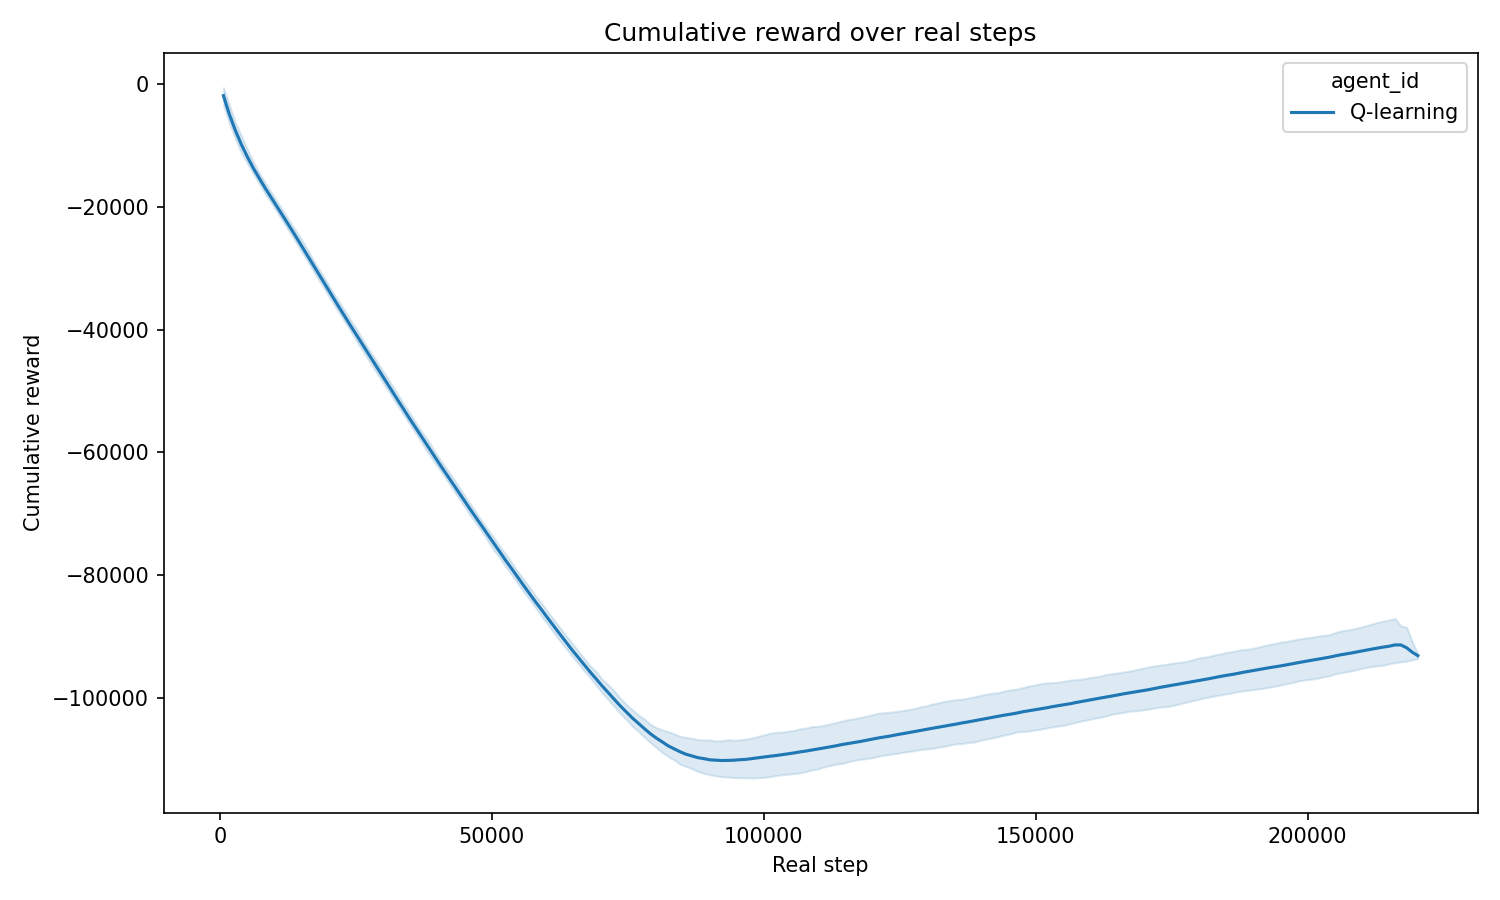

In [5]:
# DONE: Build the cumulative-reward-over-real-steps line plot.
# Consumes the `traces` DataFrame loaded in the previous cell.

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from IPython.display import Image
from visualizations import plot_cumulative_reward

LABEL_MAP = {"q_learning": "Q-learning"}

img_path = Path.cwd().parent / "img" / "v1" / "cumulative_reward.png"
img_path.parent.mkdir(parents=True, exist_ok=True)
plot_cumulative_reward(
    traces,
    img_path,
    label_map=LABEL_MAP,
    band_alpha=0.15,
)

print(f"saved: {img_path.relative_to(Path.cwd().parent)}")
Image(filename=str(img_path))

saved: img/episodes_to_optimal.png


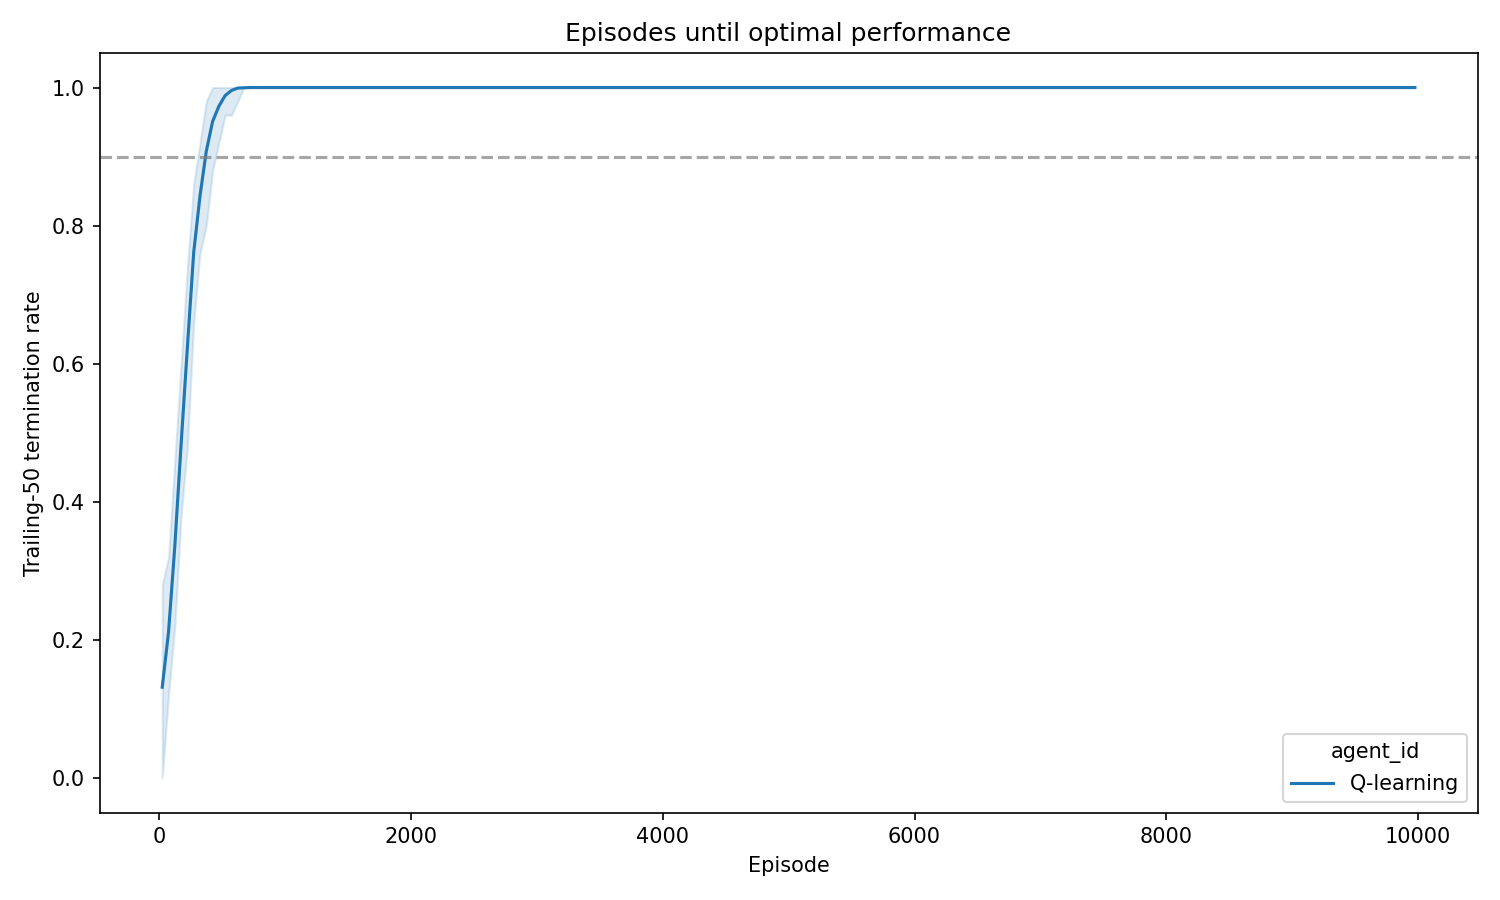

In [6]:
# DONE: Build the trailing-50 termination rate line plot (episodes-to-optimal).
# Consumes the `traces` DataFrame loaded above.

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from IPython.display import Image
from visualizations import plot_termination_rate

LABEL_MAP = {"q_learning": "Q-learning"}

img_path = Path.cwd().parent / "img" / "v1" / "episodes_to_optimal.png"
img_path.parent.mkdir(parents=True, exist_ok=True)
plot_termination_rate(
    traces,
    img_path,
    threshold=0.9,
    window=50,
    label_map=LABEL_MAP,
    band_alpha=0.15,
)

print(f"saved: {img_path.relative_to(Path.cwd().parent)}")
Image(filename=str(img_path))

saved: img/sample_efficiency.png


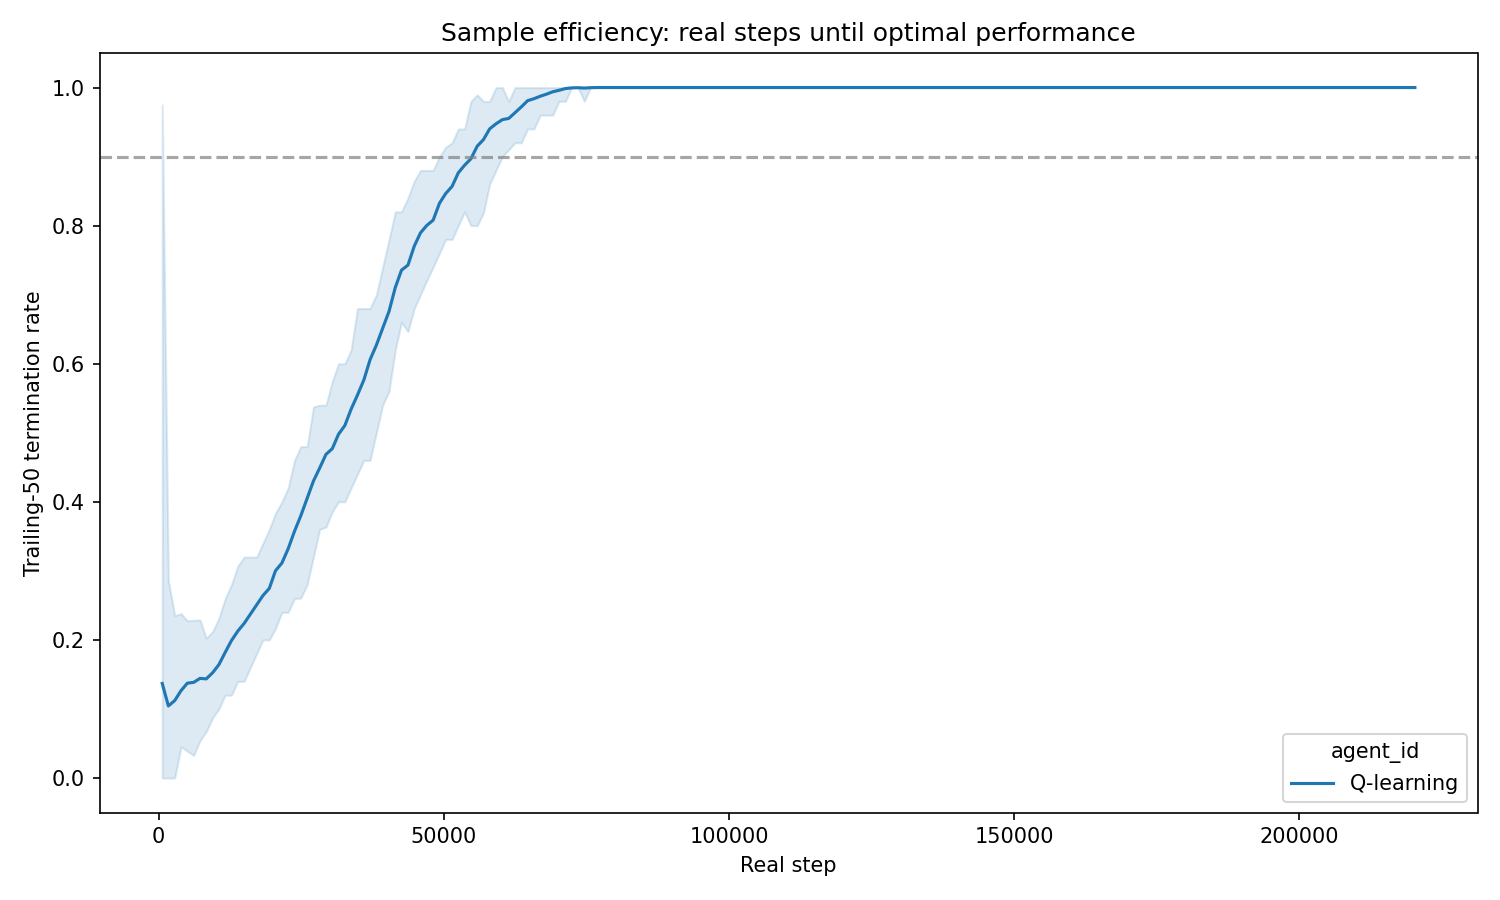

In [7]:
# DONE: Build the trailing-50 termination rate line plot (sample efficiency view).
# Consumes the `traces` DataFrame loaded above.

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from IPython.display import Image
from visualizations import plot_termination_rate

LABEL_MAP = {"q_learning": "Q-learning"}

img_path = Path.cwd().parent / "img" / "v1" / "sample_efficiency.png"
img_path.parent.mkdir(parents=True, exist_ok=True)
plot_termination_rate(
    traces,
    img_path,
    threshold=0.9,
    window=50,
    x_axis="cumulative_steps",
    label_map=LABEL_MAP,
    band_alpha=0.15,
)

print(f"saved: {img_path.relative_to(Path.cwd().parent)}")
Image(filename=str(img_path))

      agent_id  seed  steps_to_reliable_termination
0   q_learning     0                        43393.0
1   q_learning     1                        47300.0
2   q_learning     2                        45877.0
3   q_learning     3                        44703.0
4   q_learning     4                        45595.0
5   q_learning     5                        40185.0
6   q_learning     6                        46836.0
7   q_learning     7                        48301.0
8   q_learning     8                        43458.0
9   q_learning     9                        45317.0
10  q_learning    10                           94.0
11  q_learning    11                        49644.0
12  q_learning    12                          200.0
13  q_learning    13                        45733.0
14  q_learning    14                          190.0
15  q_learning    15                        45344.0
16  q_learning    16                        48138.0
17  q_learning    17                        44034.0
18  q_learni

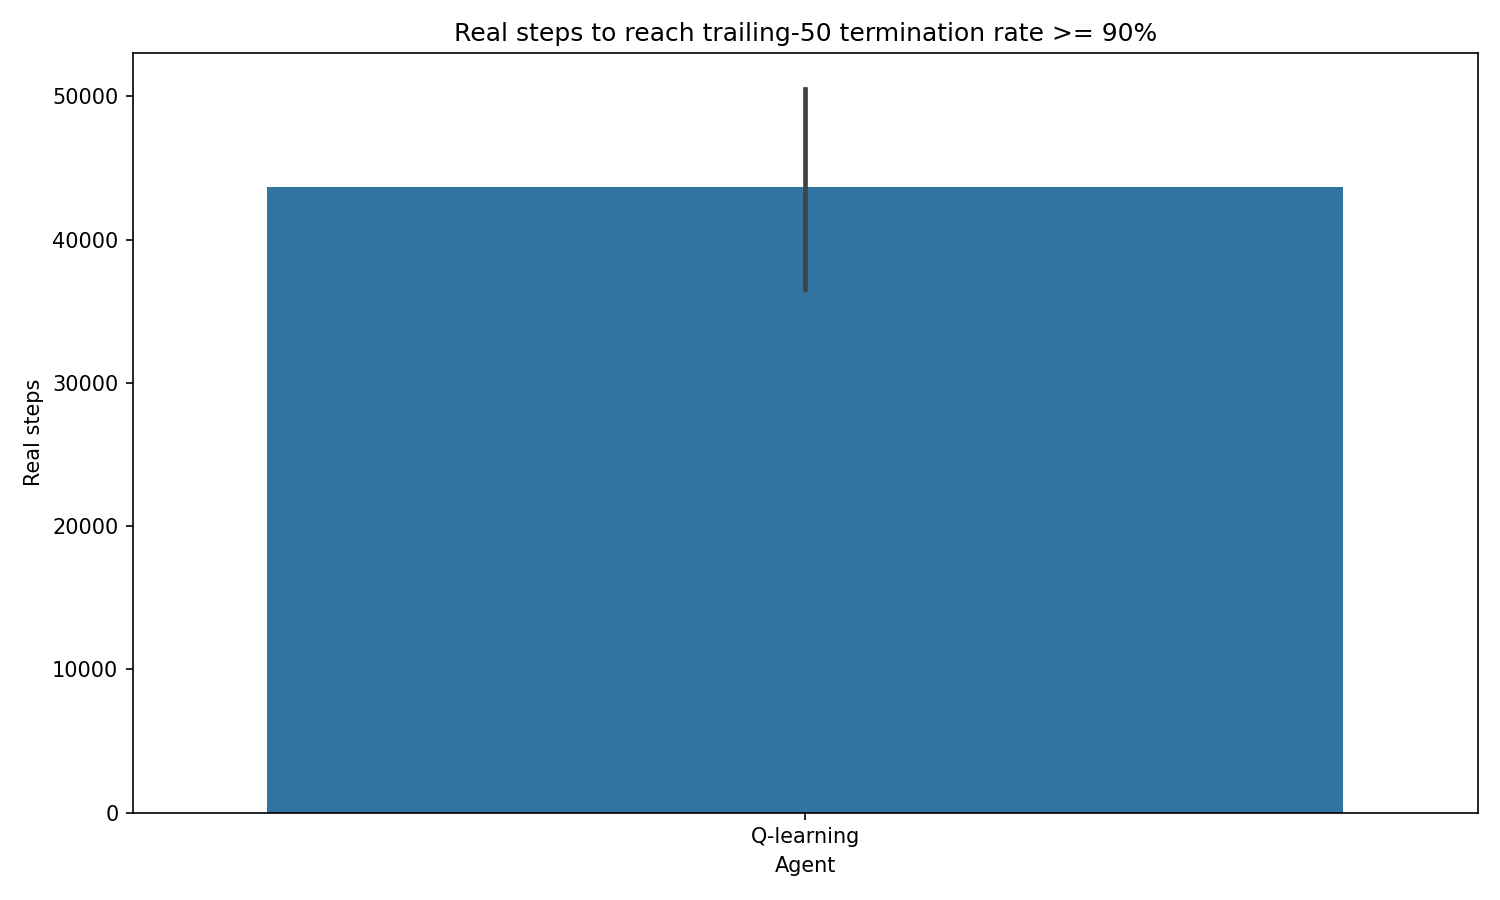

In [8]:
# DONE: Build the steps-to-reliable-termination scalar and bar chart.
# Consumes the `traces` DataFrame loaded above.

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from IPython.display import Image
from visualizations import plot_steps_to_reliable_termination, steps_to_reliable_termination

LABEL_MAP = {"q_learning": "Q-learning"}

result = steps_to_reliable_termination(traces, target_rate=0.8, window=50)
print(result.to_string())
print()

# Survival check: how many seeds per agent reached the target rate.
survival = (
    result
    .assign(reached=result["steps_to_reliable_termination"].notna())
    .groupby("agent_id")
    .agg(seeds_total=("seed", "count"), seeds_reached=("reached", "sum"))
)
print("Survival per agent (seeds that reached target_rate=0.8):")
print(survival.to_string())

img_path = Path.cwd().parent / "img" / "v1" / "steps_to_reliable_termination.png"
img_path.parent.mkdir(parents=True, exist_ok=True)
plot_steps_to_reliable_termination(
    traces,
    img_path,
    target_rate=0.9,
    window=50,
    label_map=LABEL_MAP,
)

print(f"\nsaved: {img_path.relative_to(Path.cwd().parent)}")
Image(filename=str(img_path))

## 4. Tabular model and Dyna-Q

In [1]:
# DONE: Build a TabularModel class that records deterministic experience
# and supports uniform random replay.
# Outcome: a class in src/ with update(s, a, r, s_next) that stores
# model[(s,a)] = (r, s_next), overwriting on revisit; sample(rng) that
# returns a random (s, a, r, s_next) tuple from stored transitions,
# raising ValueError when the model is empty; caller supplies the RNG
# for reproducibility.

import sys
from pathlib import Path

import numpy as np

sys.path.insert(0, str(Path.cwd().parent / "src"))

from tabular_model import TabularModel

rng = np.random.default_rng(0)
model = TabularModel()

# Populate with three transitions
model.update(s=0, a=1, r=-1.0, s_next=10)
model.update(s=1, a=3, r=-1.0, s_next=20)
model.update(s=2, a=0, r=20.0, s_next=30)
print(f"stored transitions: {len(model._transitions)}")

# Sample repeatedly and confirm only stored (s,a) pairs appear
seen = set()
for _ in range(300):
    s, a, r, s_next = model.sample(rng)
    seen.add((s, a))
print(f"(s,a) pairs seen across 300 samples: {sorted(seen)}")
print(f"expected:                            {sorted(model._transitions.keys())}")

# Overwrite an existing entry
model.update(s=0, a=1, r=99.0, s_next=99)
r_check, s_next_check = model._transitions[(0, 1)]
print(f"\nafter overwrite (0,1): r={r_check}, s_next={s_next_check}  (expected r=99.0, s_next=99)")

# ValueError on empty model
empty = TabularModel()
try:
    empty.sample(rng)
except ValueError as e:
    print(f"\nValueError on empty model: {e}")


stored transitions: 3
(s,a) pairs seen across 300 samples: [(0, 1), (1, 3), (2, 0)]
expected:                            [(0, 1), (1, 3), (2, 0)]

after overwrite (0,1): r=99.0, s_next=99  (expected r=99.0, s_next=99)

ValueError on empty model: model is empty


In [4]:
# DONE: Build a DynaQAgent class extending QLearningAgent with n planning
# steps per real step.
# Outcome: a subclass in src/ that accepts n_planning >= 1 (raises otherwise);
# overrides learn() to (1) do the real Q-update via super(), (2) update
# the TabularModel, (3) run n_planning simulated Q-updates sampled from
# the model using the agent's own RNG; returns stats dict with
# n_planning_updates and wall_time_planning keys so TrainingLoop records
# them correctly.

import sys
from pathlib import Path

import numpy as np

sys.path.insert(0, str(Path.cwd().parent / "src"))

from dyna_q_agent import DynaQAgent

agent = DynaQAgent(
    num_states=500, num_actions=6,
    alpha=0.5, epsilon=0.1, gamma=0.99,
    n_planning=5, seed=0,
)
print(f"Q-table shape: {agent.Q.shape}")
print(f"n_planning:    {agent.n_planning}")
print(f"model entries before first step: {len(agent.model._transitions)}")

# Real step: taxi picks up passenger (positive reward)
stats = agent.learn(state=100, action=4, reward=-1.0, next_state=200,
                    terminated=False, truncated=False)
print(f"\nafter step 1:")
print(f"  model entries:       {len(agent.model._transitions)}")
print(f"  n_planning_updates:  {stats['n_planning_updates']}")
print(f"  wall_time_planning:  {stats['wall_time_planning']:.6f}s")
print(f"  Q[100, 4]:           {agent.Q[100, 4]:.4f}")

# Second real step from a different state
stats = agent.learn(state=200, action=2, reward=20.0, next_state=300,
                    terminated=True, truncated=False)
print(f"\nafter step 2 (terminal, reward=20):")
print(f"  model entries:       {len(agent.model._transitions)}")
print(f"  n_planning_updates:  {stats['n_planning_updates']}")
print(f"  Q[200, 2]:           {agent.Q[200, 2]:.4f}  (planning steps push it toward 20.0)")

# ValueError on n_planning=0
try:
    DynaQAgent(num_states=500, num_actions=6, alpha=0.1,
               epsilon=0.1, gamma=0.99, n_planning=0)
except ValueError as e:
    print(f"\nValueError for n_planning=0: {e}")


Q-table shape: (500, 6)
n_planning:    5
model entries before first step: 0

after step 1:
  model entries:       1
  n_planning_updates:  5
  wall_time_planning:  0.000054s
  Q[100, 4]:           -0.9844

after step 2 (terminal, reward=20):
  model entries:       2
  n_planning_updates:  5
  Q[200, 2]:           18.7500  (expected ~10.0 from alpha=0.5, r=20)

ValueError for n_planning=0: n_planning must be >= 1, got 0


In [ ]:
# TODO: Run Dyna-Q experiments for n_planning in {5, 10, 50}.
# Outcome: one TrainingLoop run per n value writing traces to
# data/dyna_q_n5/, data/dyna_q_n10/, data/dyna_q_n50/; same episode
# count and seed range as the Q-learning baseline so results are
# directly comparable.


In [ ]:
# TODO: Visualize Dyna-Q vs Q-learning comparison (v2 plots).
# Outcome: reload traces for all four agents (q_learning, dyna_q_n5,
# dyna_q_n10, dyna_q_n50); produce cumulative-reward, termination-rate,
# and sample-efficiency plots saved to img/v2/; label_map maps each
# agent_id to a human-readable name.


## 5. Dynamic environment

## 6. Dyna-Q+

## 7. Prioritized sweeping

## 8. Convergence runs

## 9. Synthesis

## 10. Optional: NN dynamics model